# Predicting Creativity from Text Using NLP and RAG
## Project Goal
The goal of this project is to investigate whether artificial intelligence can detect creativity from text alone without any personality labels or psychological tests - simply by analyzing how a person writes.

This project explores whether a person's creativity can be predicted from the way they write.

## Data Sources
Using two real-world datasets:

- MBTI personality posts dataset
- Big Five personality test dataset with 950,000+ responses
The pipeline extracts linguistic features from raw text and combines NLP analysis with a RAG (Retrieval-Augmented Generation) system to classify individuals as creative or not creative.

## RAG System
The RAG component retrieves the most similar real personality profiles from a vector database built with Sentence Transformers and ChromaDB.

This retrieval step adds contextual intelligence to the prediction, allowing the system to compare writing patterns with similar personality profiles beyond what standard machine learning models capture.

## Machine Learning Models
Five machine learning models were trained and evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM
Logistic Regression achieved the best balance between accuracy and generalization on unseen text.

 ## Full Pipeline
 The notebook demonstrates a complete machine learning pipeline including:

- Data loading and preprocessing
- Text cleaning and NLP feature engineering
- Exploratory Data Analysis (EDA) with visualizations
- Model training and performance comparison
- Live creativity prediction from user text
Any input text can be analyzed and classified as Creative or Not Creative, along with a confidence score.

## Install & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
PALETTE = ['#845EC2','#FF6F91','#FF9671','#FFC75F','#00C9A7','#4D8B31']

print(" Libraries loaded!")

 Libraries loaded!


## Load Datasets

In [2]:
mbti_df = pd.read_csv("mbti_1/mbti_1.csv")

big5_df = pd.read_csv(
    "data-final/data-final.csv",
    sep='\t'
)

print(f" MBTI dataset:     {mbti_df.shape}")
print(f" Big Five dataset: {big5_df.shape}")
print(f"\nMBTI types:\n{mbti_df['type'].value_counts()}")
mbti_df.head(3)

 MBTI dataset:     (8675, 2)
 Big Five dataset: (1015341, 110)

MBTI types:
type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...


## Clean Big Five Dataset

In [3]:
opn_cols = [f'OPN{i}' for i in range(1, 11)]
ext_cols = [f'EXT{i}' for i in range(1, 11)]

print(f"Openness columns: {opn_cols}")

big5_clean = big5_df[opn_cols + ext_cols + ['country']].copy()
big5_clean = big5_clean.replace(0, np.nan).dropna()
big5_clean = big5_clean[
    big5_clean[opn_cols].apply(lambda row: row.between(1, 5).all(), axis=1)
]

big5_clean['OPN_score'] = big5_clean[opn_cols].mean(axis=1)
big5_clean['EXT_score'] = big5_clean[ext_cols].mean(axis=1)

threshold = big5_clean['OPN_score'].median()
big5_clean['Is_Creative'] = (big5_clean['OPN_score'] >= threshold).astype(int)

print(f"\n Cleaned Big Five: {big5_clean.shape}")
print(f"Threshold (median): {threshold:.2f}")
print(f"Creative:     {big5_clean['Is_Creative'].sum()}")
print(f"Not Creative: {(big5_clean['Is_Creative']==0).sum()}")
big5_clean[['OPN_score', 'EXT_score', 'Is_Creative']].head()

Openness columns: ['OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10']

 Cleaned Big Five: (951528, 24)
Threshold (median): 3.30
Creative:     532486
Not Creative: 419042


,OPN_score,EXT_score,Is_Creative
0,3.3,3.0,1
1,2.7,3.4,0
2,3.1,2.9,0
3,3.1,2.6,0
4,3.6,3.5,1


## Process MBTI Text Data

In [4]:
""" the original approach was to label creativity based on MBTI types,
    but it was too simplistic and not data-driven.
    Instead, we will use NLP features from the posts to cluster users and identify 
    which cluster is more creative based on the signal ratio and unique word usage.
    This way, we can derive a more meaningful 'Is_Creative' label for the MBTI dataset.
    
CREATIVE_TYPES = ['ENFP','INFP','ENTP','INTP','ENFJ','INFJ','ISFP','ESFP']
mbti_df['Is_Creative'] = mbti_df['type'].apply(
    lambda x: 1 if x in CREATIVE_TYPES else 0
)
"""

# Define a function to extract NLP features from text
def extract_nlp_features(text):
    text_lower = text.lower()
    words      = text_lower.split()
    sentences  = re.split(r'[.!?]+', text_lower)

    creative_words   = ['imagine','dream','create','invent','design','explore',
                        'original','unique','art','music','write','paint','idea',
                        'innovate','experiment','vision','inspire','emotion','feel',
                        'fantasy','curious','wonder','novel','unusual','love','beautiful']
    analytical_words = ['data','logic','process','method','system','rule',
                        'procedure','fact','measure','plan','structured','precise',
                        'consistent','efficient','technical','analysis','calculate']

    creative_count   = sum(1 for w in words if w in creative_words)
    analytical_count = sum(1 for w in words if w in analytical_words)
    avg_sent_len     = np.mean([len(s.split()) for s in sentences if s.strip()]) if sentences else 0
    unique_ratio     = len(set(words)) / (len(words) + 1)

    return pd.Series({
        'total_words':        len(words),
        'unique_words':       len(set(words)),
        'unique_ratio':       round(unique_ratio, 4),
        'creative_signals':   creative_count,
        'analytical_signals': analytical_count,
        'signal_ratio':       round(creative_count / (analytical_count + 1), 4),
        'avg_sent_length':    round(avg_sent_len, 2),
        'exclamations':       text.count('!'),
        'questions_used':     text.count('?'),
        'links_count':        len(re.findall(r'http\S+', text)),
    })

print(" Extracting NLP features ...")
nlp_feats = mbti_df['posts'].apply(extract_nlp_features)

cluster_cols = ['total_words', 'unique_ratio', 'creative_signals', 'signal_ratio', 'avg_sent_length']
X_cluster = nlp_feats[cluster_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

nlp_feats['Cluster_ID'] = kmeans.fit_predict(X_scaled)

cluster_summary = nlp_feats.groupby('Cluster_ID')[cluster_cols].mean()
print("Cluster results comparison (to see which cluster has a higher signal_ratio and unique_ratio)")
print(cluster_summary)

creative_cluster_id = cluster_summary['signal_ratio'].idxmax()
mbti_df['Is_Creative'] = (nlp_feats['Cluster_ID'] == creative_cluster_id).astype(int)

print("Cluster result validation")
sil_score = silhouette_score(X_scaled, nlp_feats['Cluster_ID'], sample_size=10000, random_state=42)
ch_score = calinski_harabasz_score(X_scaled, nlp_feats['Cluster_ID'])

print(f"Silhouette Score: {sil_score:.4f} (The closer to 1, the better; >0.2 is considered significant.)")
print(f"Calinski-Harabasz: {ch_score:.2f} (The higher the better, indicating high cluster separation)\n")

mbti_features = pd.concat([nlp_feats, mbti_df[['type','Is_Creative']]], axis=1)

mbti_features['I_E'] = mbti_df['type'].apply(lambda x: 1 if x[0]=='E' else 0)
mbti_features['N_S'] = mbti_df['type'].apply(lambda x: 1 if x[1]=='N' else 0)
mbti_features['T_F'] = mbti_df['type'].apply(lambda x: 1 if x[2]=='T' else 0)
mbti_features['J_P'] = mbti_df['type'].apply(lambda x: 1 if x[3]=='J' else 0)

print(f"\n MBTI features extracted: {mbti_features.shape}")
print(f"Creative:     {mbti_features['Is_Creative'].sum()}")
print(f"Not Creative: {(mbti_features['Is_Creative']==0).sum()}")
mbti_features.head(3)

 Extracting NLP features ...
Cluster results comparison (to see which cluster has a higher signal_ratio and unique_ratio)
            total_words  unique_ratio  creative_signals  signal_ratio  \
Cluster_ID                                                              
0           1408.904365      0.462844          9.522421      5.895890   
1            972.975791      0.542867          4.379367      2.816544   

            avg_sent_length  
Cluster_ID                   
0                  11.59123  
1                   9.37784  
Cluster result validation
Silhouette Score: 0.2746 (The closer to 1, the better; >0.2 is considered significant.)
Calinski-Harabasz: 3795.92 (The higher the better, indicating high cluster separation)


 MBTI features extracted: (8675, 17)
Creative:     5040
Not Creative: 3635


,total_words,unique_words,unique_ratio,creative_signals,analytical_signals,signal_ratio,avg_sent_length,exclamations,questions_used,links_count,Cluster_ID,type,Is_Creative,I_E,N_S,T_F,J_P
0,556.0,365.0,0.6553,2.0,0.0,2.0000,5.13,3.0,18.0,18.0,1,INFJ,0,0,1,0,1
1,1170.0,571.0,0.4876,2.0,0.0,2.0000,8.02,0.0,5.0,8.0,1,ENTP,0,1,1,1,0
2,836.0,486.0,0.5806,4.0,2.0,1.3333,10.53,4.0,12.0,5.0,1,INTP,0,0,1,1,0


## Class Distribution

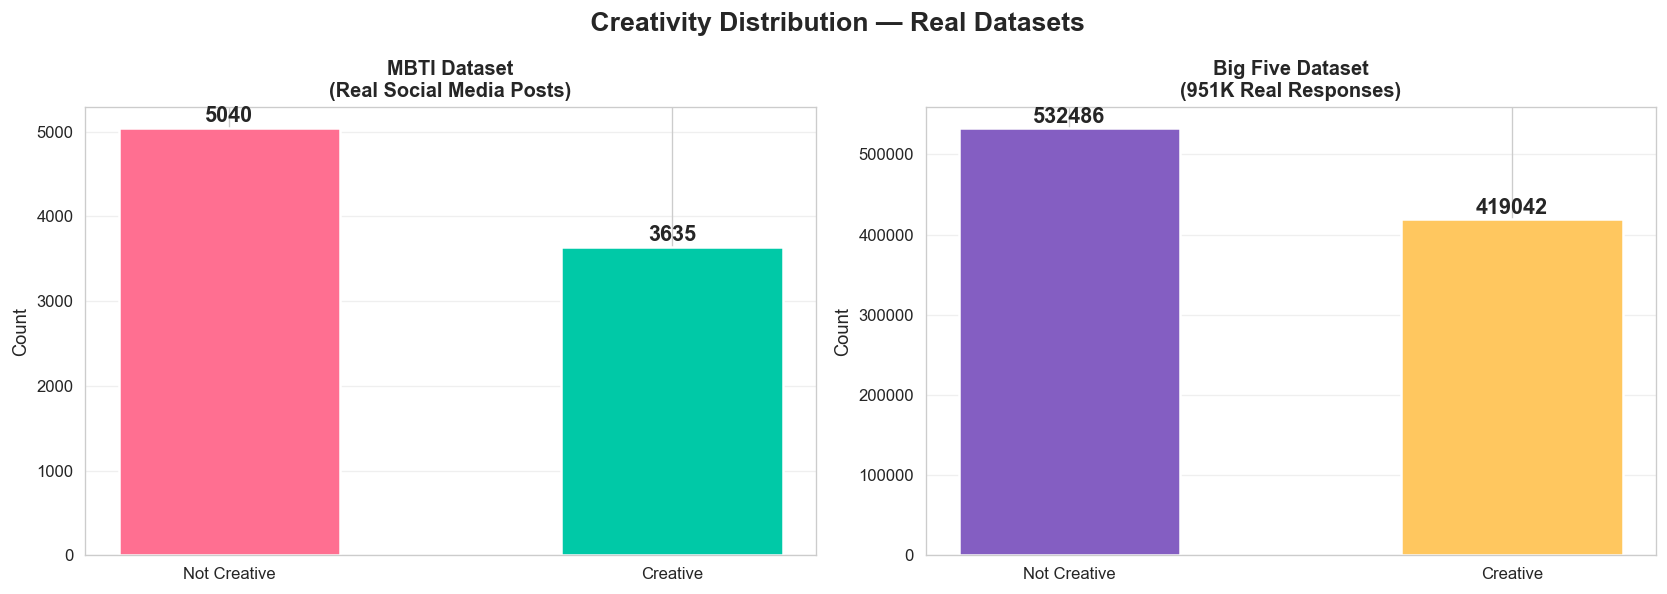

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Creativity Distribution — Real Datasets', fontsize=16, fontweight='bold')

counts1 = mbti_features['Is_Creative'].value_counts()
bars1 = axes[0].bar(['Not Creative','Creative'], counts1.values,
                     color=['#FF6F91','#00C9A7'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars1, counts1.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title('MBTI Dataset\n(Real Social Media Posts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

counts2 = big5_clean['Is_Creative'].value_counts()
bars2 = axes[1].bar(['Not Creative','Creative'], counts2.values,
                     color=['#845EC2','#FFC75F'], edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars2, counts2.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[1].set_title('Big Five Dataset\n(951K Real Responses)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## MBTI Type Creativity Rate

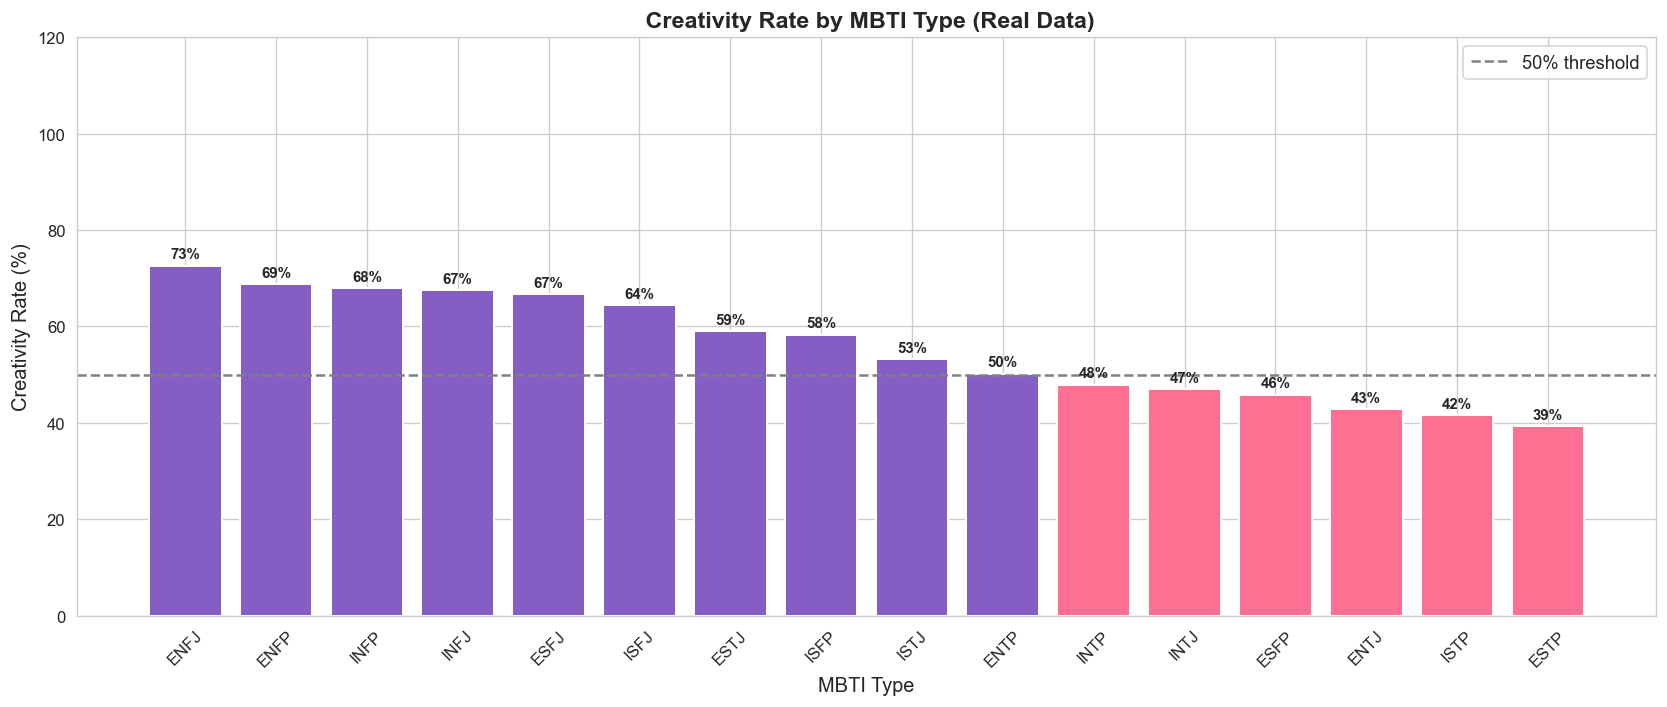

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

type_rate = mbti_features.groupby('type')['Is_Creative'].mean().sort_values(ascending=False)
colors_bar = ['#00C9A7' if v == 1.0 else '#845EC2' if v > 0.5 else '#FF6F91'
              for v in type_rate.values]

bars = ax.bar(type_rate.index, type_rate.values * 100,
              color=colors_bar, edgecolor='white', linewidth=1.2)
ax.axhline(50, color='gray', linestyle='--', lw=1.5, label='50% threshold')

for bar, val in zip(bars, type_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
            f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')

ax.set_title(' Creativity Rate by MBTI Type (Real Data)', fontsize=14, fontweight='bold')
ax.set_xlabel('MBTI Type', fontsize=12)
ax.set_ylabel('Creativity Rate (%)', fontsize=12)
ax.set_ylim(0, 120)
ax.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## NLP Features Distributions

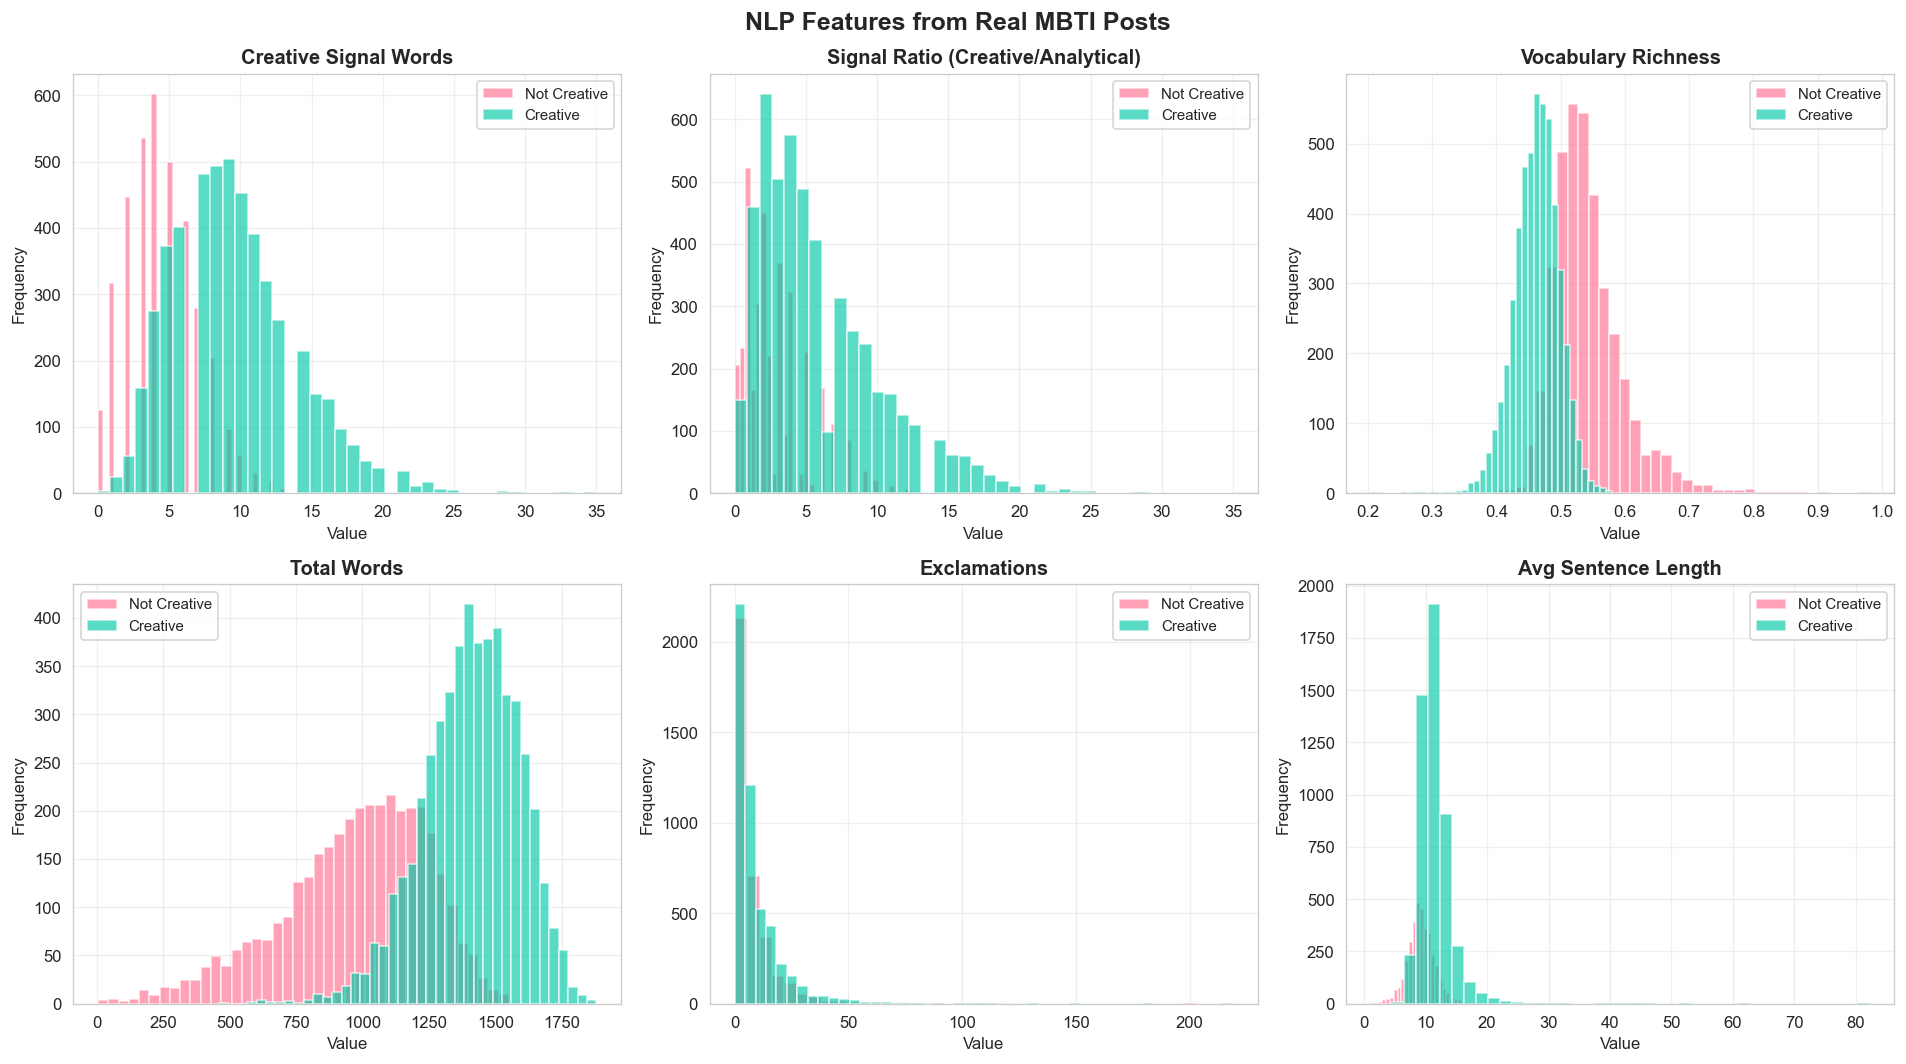

In [7]:
feats_plot  = ['creative_signals','signal_ratio','unique_ratio',
               'total_words','exclamations','avg_sent_length']
titles_plot = ['Creative Signal Words','Signal Ratio (Creative/Analytical)',
               'Vocabulary Richness','Total Words','Exclamations','Avg Sentence Length']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(' NLP Features from Real MBTI Posts', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (feat, title) in enumerate(zip(feats_plot, titles_plot)):
    for cls, color, lbl in zip([0,1], ['#FF6F91','#00C9A7'],
                                ['Not Creative','Creative']):
        axes[i].hist(mbti_features[mbti_features['Is_Creative']==cls][feat],
                     bins=40, alpha=0.65, color=color, label=lbl, edgecolor='white')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation Heatmap

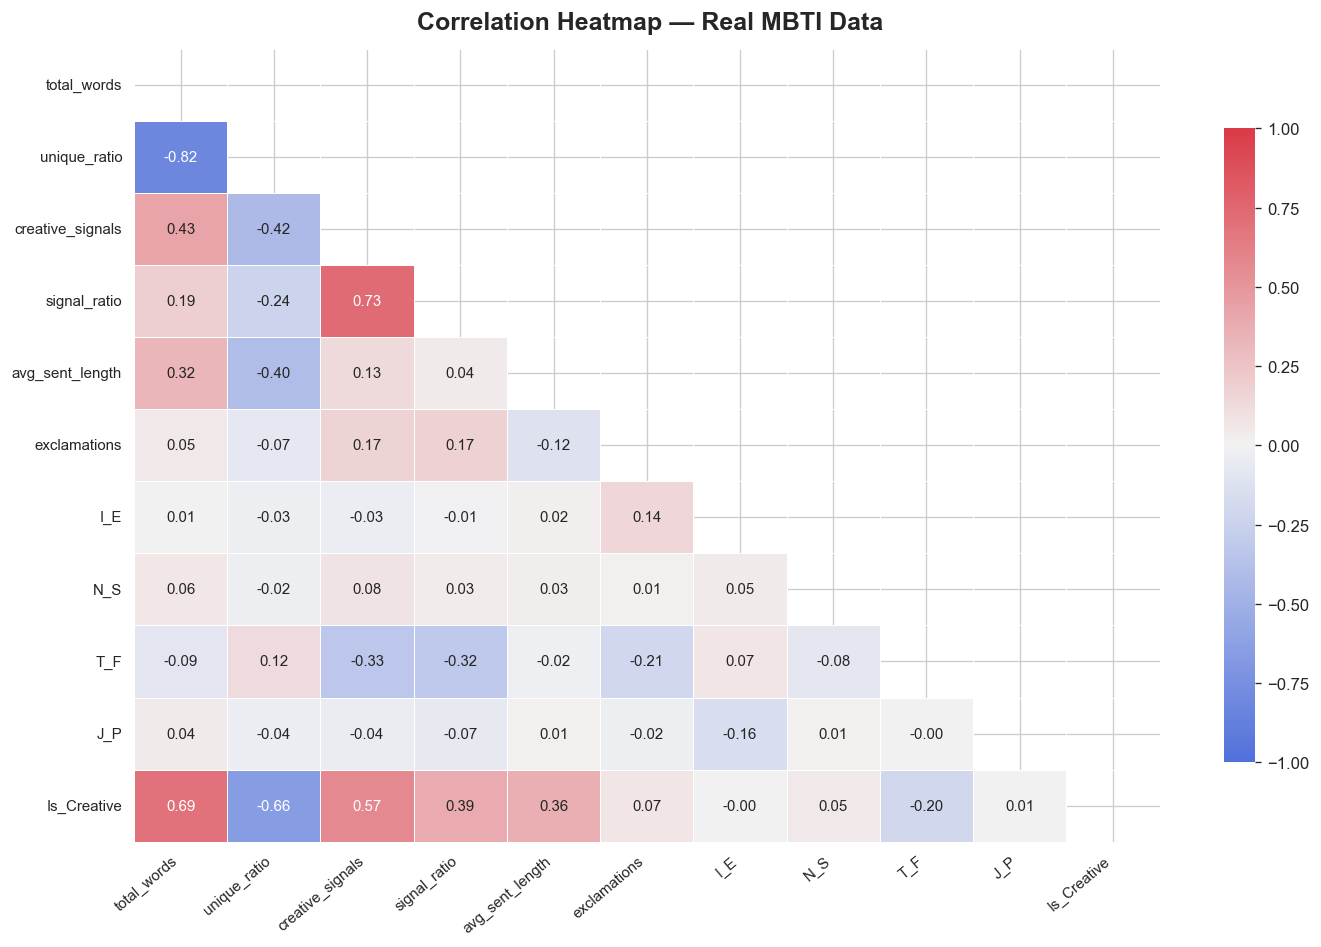

In [8]:
corr_cols = ['total_words','unique_ratio','creative_signals','signal_ratio',
             'avg_sent_length','exclamations','I_E','N_S','T_F','J_P','Is_Creative']

fig, ax = plt.subplots(figsize=(12, 8))
corr = mbti_features[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(260, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'size': 9}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})

ax.set_title(' Correlation Heatmap — Real MBTI Data', fontsize=15, fontweight='bold', pad=12)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## Build RAG Knowledge Base

In [9]:
# set cuda/mps if available, else cpu
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
embeder = SentenceTransformer('all-MiniLM-L6-v2', device=device)
chroma_client = chromadb.Client(Settings(anonymized_telemetry=False))
collection = chroma_client.create_collection(
    name = "creativity_profile",
    metadata = {"hnsw:space": "cosine"}
)

"""原作者写出来的代码，但我们用自己写出来的更准确的分类
CREATIVE_TYPES = ['ENFP','INFP','ENTP','INTP','ENFJ','INFJ','ISFP','ESFP']
creative_samples    = mbti_df[mbti_df['type'].isin(CREATIVE_TYPES)].sample(5, random_state=42)
noncreative_samples = mbti_df[~mbti_df['type'].isin(CREATIVE_TYPES)].sample(5, random_state=42)
"""

creative_samples = mbti_df[mbti_df['Is_Creative'] == 1].sample(5, random_state=42)
noncreative_samples = mbti_df[mbti_df['Is_Creative'] == 0].sample(5, random_state=42)

kb_samples = pd.concat([creative_samples, noncreative_samples]).reset_index(drop=True)
kb_samples['label'] = [1]*5 + [0]*5
kb_samples['kb_id'] = [f"kb_{i}" for i in range(10)]
kb_samples['text_short'] = kb_samples['posts'].str[:500]

embeddings = embeder.encode(kb_samples['text_short'].tolist()).tolist()

collection.add(
    ids = kb_samples['kb_id'].tolist(),
    documents = kb_samples['text_short'].tolist(),
    embeddings = embeddings,
    metadatas = [{'label': int(r['label']), 'mbti_type': r['type']} for _, r in kb_samples.iterrows()]
)

print(f" RAG Knowledge Base ready: {collection.count()} real profiles")
print(kb_samples[['type','label']])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17688.07it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 RAG Knowledge Base ready: 10 real profiles
   type  label
0  INFP      1
1  INFP      1
2  INFJ      1
3  INFP      1
4  INTJ      1
5  INTJ      0
6  INTJ      0
7  ENTJ      0
8  ENTJ      0
9  INTJ      0


# NLP features